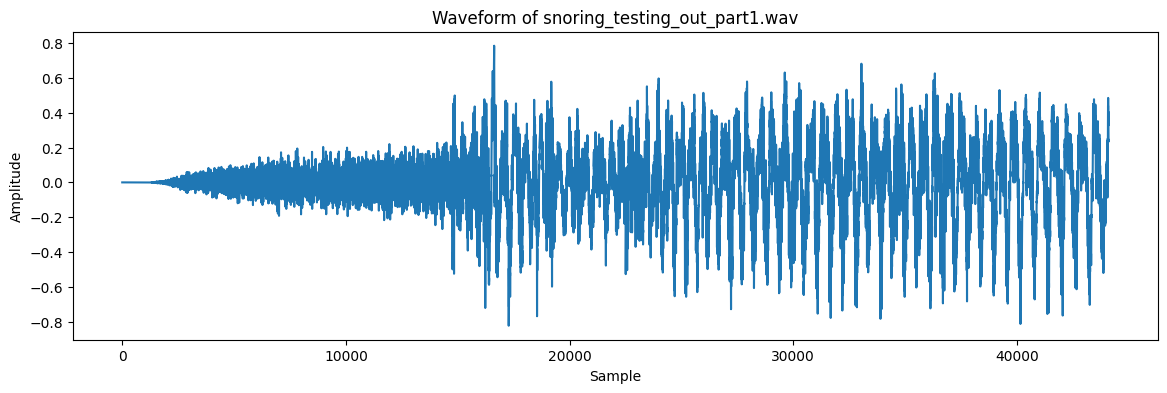

In [89]:
import matplotlib.pyplot as plt
import librosa
import os
def plot_waveform(file_path):
    # Load audio file
    audio, sr = librosa.load(file_path, sr=None)
    plt.figure(figsize=(14, 4))
    plt.plot(audio)
    plt.title(f'Waveform of {os.path.basename(file_path)}')
    plt.xlabel('Sample')
    plt.ylabel('Amplitude')
    plt.show()
plot_waveform('/home/lee/work/CP/Snore-Guard/test_sound/snoring_testing_out_part1.wav')

In [1]:
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from IPython import display

# Set the seed value for experiment reproducibility.
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

2025-06-02 13:40:33.258321: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-02 13:40:33.390462: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-02 13:40:33.529845: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748846433.671360   21908 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748846433.716461   21908 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-02 13:40:34.004765: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

The dataset consisting of 500 background noises and 500 snoring noises was uploaded to my google drive. You can get the dataset from https://www.kaggle.com/datasets/tareqkhanemu/snoring

In [48]:
DATASET_PATH = '/home/lee/work/CP/newdata'

data_dir = pathlib.Path(DATASET_PATH)


In [49]:
commands = np.array(tf.io.gfile.listdir(str(data_dir)))
print('Commands:', commands)

Commands: ['snoring' 'background']


The code below downsamples 44.1 kHz audio sample to 8 kHz, which is what's needed for the microcontroller to be fast.

In [50]:
import librosa
import soundfile as sf
# Your new sampling rate
new_rate = 16000
for file in os.listdir(f'{DATASET_PATH}/background'):
  y, s = librosa.load(f'{DATASET_PATH}/background/{file}', sr=new_rate) # Downsample 44.1kHz to 8kHz
  sf.write(f'{DATASET_PATH}/background/{file}', y, new_rate, 'PCM_16')
for file in os.listdir(f'{DATASET_PATH}/snoring'):
  y, s = librosa.load(f'{DATASET_PATH}/snoring/{file}', sr=new_rate) # Downsample 44.1kHz to 8kHz
  sf.write(f'{DATASET_PATH}/snoring/{file}', y, new_rate, 'PCM_16')

In [51]:
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=data_dir,
    batch_size=64,
    validation_split=0.2,
    seed=0,
    output_sequence_length=16000,
    subset='both')

label_names = np.array(train_ds.class_names)
print()
print("label names:", label_names)

Found 1618 files belonging to 2 classes.
Using 1295 files for training.
Using 323 files for validation.

label names: ['background' 'snoring']


The dataset now contains batches of audio clips and integer labels. The audio clips have a shape of `(batch, samples, channels)`.

This dataset only contains single channel audio, so use the `tf.squeeze` function to drop the extra axis:

In [52]:
def squeeze(audio, labels):
  audio = tf.squeeze(audio, axis=-1)
  return audio, labels

train_ds = train_ds.map(squeeze, tf.data.AUTOTUNE)
val_ds = val_ds.map(squeeze, tf.data.AUTOTUNE)


In [53]:
test_ds = val_ds.shard(num_shards=2, index=0)
val_ds = val_ds.shard(num_shards=2, index=1)

In [54]:
for example_audio, example_labels in train_ds.take(1):
  print(example_audio.shape)
  print(example_labels.shape)

(64, 16000)
(64,)


Let's plot a few audio waveforms:

In [55]:
label_names[[1,1]]

array(['snoring', 'snoring'], dtype='<U10')

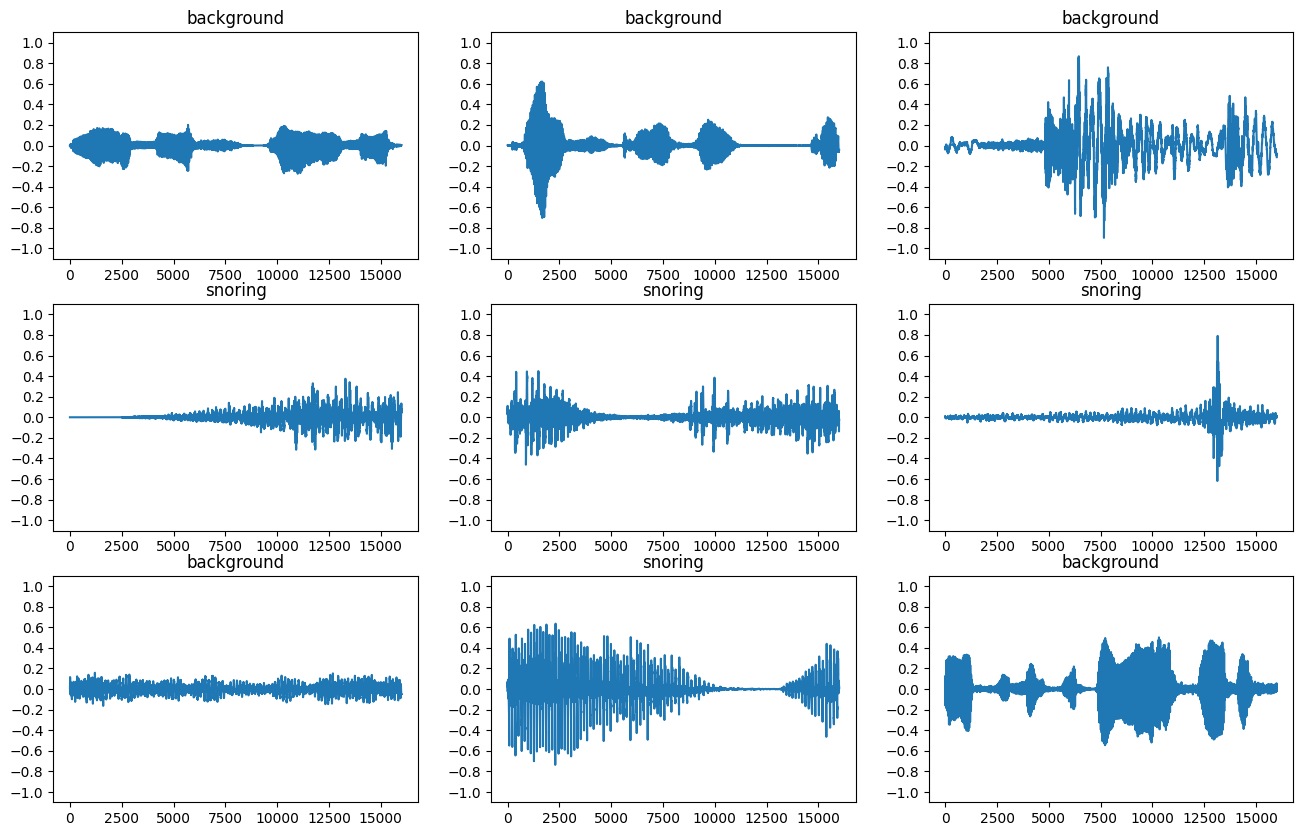

In [56]:
plt.figure(figsize=(16, 10))
rows = 3
cols = 3
n = rows * cols
for i in range(n):
  plt.subplot(rows, cols, i+1)
  audio_signal = example_audio[i]
  plt.plot(audio_signal)
  plt.title(label_names[example_labels[i]])
  plt.yticks(np.arange(-1.2, 1.2, 0.2))
  plt.ylim([-1.1, 1.1])

## Convert waveforms to spectrograms

The waveforms in the dataset are represented in the time domain. Next, you'll transform the waveforms from the time-domain signals into the time-frequency-domain signals by computing the [short-time Fourier transform (STFT)](https://en.wikipedia.org/wiki/Short-time_Fourier_transform) to convert the waveforms to as [spectrograms](https://en.wikipedia.org/wiki/Spectrogram), which show frequency changes over time and can be represented as 2D images.

Additionally, we will apply log scale and mel-scale to these spectrograms to reduce the data size.

A Fourier transform (`tf.signal.fft`) converts a signal to its component frequencies, but loses all time information. In comparison, STFT (`tf.signal.stft`) splits the signal into windows of time and runs a Fourier transform on each window, preserving some time information, and returning a 2D tensor that you can run standard convolutions on.

Create a utility function for converting waveforms to spectrograms:

- The waveforms need to be of the same length, so that when you convert them to spectrograms, the results have similar dimensions. This can be done by simply zero-padding the audio clips that are shorter than one second (using `tf.zeros`).
- When calling `tf.signal.stft`, choose the `frame_length` and `frame_step` parameters such that the generated spectrogram "image" is almost square. For more information on the STFT parameters choice, refer to [this Coursera video](https://www.coursera.org/lecture/audio-signal-processing/stft-2-tjEQe) on audio signal processing and STFT.
- The STFT produces an array of complex numbers representing magnitude and phase. However, in this tutorial you'll only use the magnitude, which you can derive by applying `tf.abs` on the output of `tf.signal.stft`.

In [2]:
def get_log_mel(waveform):
  stfts = tf.signal.stft(
      waveform, frame_length=512, frame_step=256)
  # Obtain the magnitude of the STFT.
  spectrograms = tf.abs(stfts)
  # Warp the linear scale spectrograms into the mel-scale.
  num_spectrogram_bins = stfts.shape[-1]
  lower_edge_hertz, upper_edge_hertz, num_mel_bins = 40.0, 6000.0, 30
  linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
    num_mel_bins, num_spectrogram_bins, 16000, lower_edge_hertz,
    upper_edge_hertz)
  mel_spectrograms = tf.tensordot(
    spectrograms, linear_to_mel_weight_matrix, 1)
  mel_spectrograms.set_shape(spectrograms.shape[:-1].concatenate(
    linear_to_mel_weight_matrix.shape[-1:]))

  # Compute a stabilized log to get log-magnitude mel-scale spectrograms.
  log_mel_spectrograms = tf.math.log(mel_spectrograms + 1e-6)
  log_mel_spectrograms = tf.reshape(log_mel_spectrograms, [-1,1830])
  return log_mel_spectrograms

In [3]:
def get_log_mel_not_flat(waveform):
  stfts = tf.signal.stft(
      waveform, frame_length=512, frame_step=256)
  # Obtain the magnitude of the STFT.
  spectrograms = tf.abs(stfts)
  # Warp the linear scale spectrograms into the mel-scale.
  num_spectrogram_bins = stfts.shape[-1]
  lower_edge_hertz, upper_edge_hertz, num_mel_bins = 40.0, 6000.0, 30
  linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
    num_mel_bins, num_spectrogram_bins, 16000, lower_edge_hertz,
    upper_edge_hertz)
  mel_spectrograms = tf.tensordot(
    spectrograms, linear_to_mel_weight_matrix, 1)
  mel_spectrograms.set_shape(spectrograms.shape[:-1].concatenate(
    linear_to_mel_weight_matrix.shape[-1:]))

  # Compute a stabilized log to get log-magnitude mel-scale spectrograms.
  log_mel_spectrograms = tf.math.log(mel_spectrograms + 1e-6)
  log_mel_spectrograms = log_mel_spectrograms[..., tf.newaxis]
  return log_mel_spectrograms

Next, start exploring the data. Print the shapes of one example's tensorized waveform and the corresponding spectrogram, and play the original audio:

Label: snoring
Waveform shape: (16000,)
log mel shape: (61, 30, 1)
Audio playback


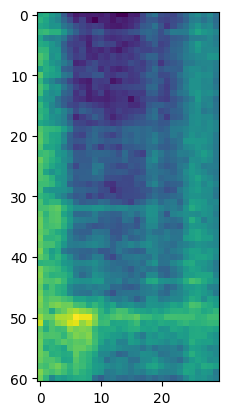

In [59]:
label = label_names[example_labels[5]]
waveform = example_audio[5]
log_mel = get_log_mel_not_flat(waveform)

print('Label:', label)
print('Waveform shape:', waveform.shape)
print('log mel shape:', log_mel.shape)
print('Audio playback')
display.display(display.Audio(waveform, rate=16000))
plt.imshow(log_mel)

Now, create spectrogramn datasets from the audio datasets:

In [60]:
def make_log_mel_ds(ds):
  return ds.map(
      map_func=lambda audio,label: (get_log_mel(audio), label),
      num_parallel_calls=tf.data.AUTOTUNE)
def make_log_mel_not_flat_ds(ds):
  return ds.map(
      map_func=lambda audio,label: (get_log_mel_not_flat(audio), label),
      num_parallel_calls=tf.data.AUTOTUNE)

In [61]:
train_log_mel_ds = make_log_mel_ds(train_ds)
val_log_mel_ds = make_log_mel_ds(val_ds)
test_log_mel_ds = make_log_mel_ds(test_ds)
train_log_mel_not_flat_ds = make_log_mel_not_flat_ds(train_ds)

Examine the spectrograms for different examples of the dataset:

In [62]:
for example_log_mels, example_lm_labels in train_log_mel_ds.take(1):
  break

## Build and train the model

Add `Dataset.cache` and `Dataset.prefetch` operations to reduce read latency while training the model:

In [109]:
train_log_mel_ds = train_log_mel_ds.cache().shuffle(10000).prefetch(tf.data.AUTOTUNE)
val_log_mel_ds = val_log_mel_ds.cache().prefetch(tf.data.AUTOTUNE)
test_log_mel_ds = test_log_mel_ds.cache().prefetch(tf.data.AUTOTUNE)

For the model, you'll use a simple convolutional neural network (CNN), since you have transformed the audio files into spectrogram images.

Your `tf.keras.Sequential` model will use the following Keras preprocessing layers:

- `tf.keras.layers.Resizing`: to downsample the input to enable the model to train faster.
- `tf.keras.layers.Normalization`: to normalize each pixel in the image based on its mean and standard deviation.

For the `Normalization` layer, its `adapt` method would first need to be called on the training data in order to compute aggregate statistics (that is, the mean and the standard deviation).

In [110]:
input_shape = example_log_mels.shape[1:]
print('Input shape:', input_shape)
num_labels = len(label_names)

# Instantiate the `tf.keras.layers.Normalization` layer.
norm_layer = layers.Normalization()
# Fit the state of the layer to the spectrograms
# with `Normalization.adapt`.
norm_layer.adapt(data=train_log_mel_not_flat_ds.map(map_func=lambda spec, label: spec))

model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Reshape((61,30,1)),
    # Downsample the input.
    layers.Resizing(32, 30),
    # Normalize.
    norm_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D((2,2)),
    # layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid'),
])

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

Input shape: (1830,)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_9 (Reshape)             │ (None, 61, 30, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_9 (Resizing)           │ (None, 32, 30, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_9 (Normalization) │ (None, 32, 30, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 30, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 15, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 13, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,468 (619.02 KB)

 Trainable params: 158,465 (619.00 KB)

 Non-trainable params: 3 (16.00 B)

Configure the Keras model with the Adam optimizer and the cross-entropy loss:

Train the model over 10 epochs for demonstration purposes:

In [111]:
EPOCHS = 20

# Tạo callback để lưu mô hình tại mỗi epoch
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='/home/lee/work/CP/snore-recognition/model_checkpoint/model_epoch_{epoch:02d}.keras',
    save_weights_only=False,     # lưu cả cấu trúc + trọng số
    save_best_only=False,        # lưu tất cả các epoch
    verbose=1
)

# EarlyStopping như cũ
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    verbose=1,
    patience=2
)
history = model.fit(
    train_log_mel_ds,
    validation_data=val_log_mel_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint_callback, early_stopping_callback],
)

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5546 - loss: 0.6771
Epoch 1: saving model to /home/lee/work/CP/snore-recognition/model_checkpoint/model_epoch_01.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.5562 - loss: 0.6760 - val_accuracy: 0.6565 - val_loss: 0.5759
Epoch 2/20
20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6775 - loss: 0.5526
Epoch 2: saving model to /home/lee/work/CP/snore-recognition/model_checkpoint/model_epoch_02.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6800 - loss: 0.5495 - val_accuracy: 0.7710 - val_loss: 0.4323
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7534 - loss: 0.4736
Epoch 3: saving model to /home/lee/work/CP/snore-recognition/model_checkpoint/model_epoch_03.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7550 - loss: 0.4720 - val_accuracy: 0.9008 - val_loss: 0.2899
Epoch 4/20
20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8624 - loss: 0.3166
Epoch 4: saving

Let's plot the training and validation loss curves to check how your model has improved during training:

Text(0, 0.5, 'Accuracy [%]')

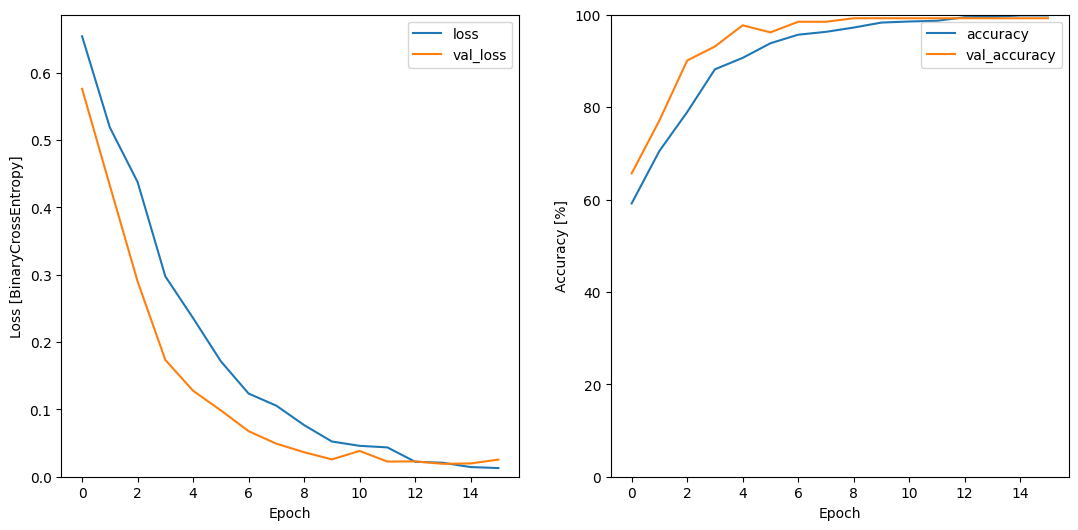

In [112]:
metrics = history.history
plt.figure(figsize=(13,6))
plt.subplot(1,2,1)
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [BinaryCrossEntropy]')

plt.subplot(1,2,2)
plt.plot(history.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')

## Evaluate the model performance

Run the model on the test set and check the model's performance:

In [130]:
print('Evaluate on test set:')
model.evaluate(test_log_mel_ds, return_dict=True)
print('Evaluate on validation set:')
model.evaluate(val_log_mel_ds, return_dict=True)
print('Evaluate on training set:')
model.evaluate(train_log_mel_ds, return_dict=True)

Evaluate on test set:
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9688 - loss: 0.1342
Evaluate on validation set:
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9903 - loss: 0.0301
Evaluate on training set:
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0052


{'accuracy': 1.0, 'loss': 0.005856976378709078}

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


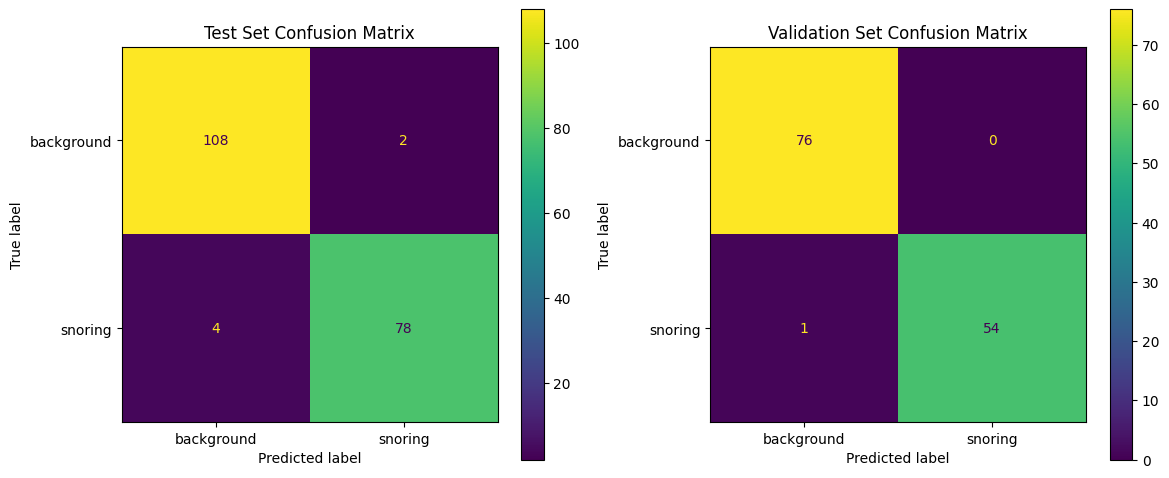

In [116]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get true and predicted labels for test set
y_true_test = []
y_pred_test = []
for x_batch, y_batch in test_log_mel_ds:
    preds = model.predict(x_batch)
    preds = (preds >= 0.5).astype(int).flatten()
    y_true_test.extend(y_batch.numpy())
    y_pred_test.extend(preds)

# Get true and predicted labels for validation set
y_true_val = []
y_pred_val = []
for x_batch, y_batch in val_log_mel_ds:
    preds = model.predict(x_batch)
    preds = (preds >= 0.5).astype(int).flatten()
    y_true_val.extend(y_batch.numpy())
    y_pred_val.extend(preds)

# Compute confusion matrices
cm_test = confusion_matrix(y_true_test, y_pred_test)
cm_val = confusion_matrix(y_true_val, y_pred_val)

# Plot both confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_test, display_labels=label_names).plot(ax=axes[0], colorbar=True)
axes[0].set_title('Test Set Confusion Matrix')
ConfusionMatrixDisplay(cm_val, display_labels=label_names).plot(ax=axes[1], colorbar=True)
axes[1].set_title('Validation Set Confusion Matrix')
plt.tight_layout()
plt.show()

In [2]:
from sklearn.metrics import classification_report

# Get true and predicted labels for test set
y_true_test = []
y_pred_test = []
for x_batch, y_batch in test_log_mel_ds:
    preds = model.predict(x_batch)
    preds = (preds >= 0.5).astype(int).flatten()
    y_true_test.extend(y_batch.numpy())
    y_pred_test.extend(preds)

# Print classification report
print(classification_report(y_true_test, y_pred_test, target_names=label_names))

NameError: name 'test_log_mel_ds' is not defined

Classification Report for Test Set:


NameError: name 'y_true_test' is not defined

### Display a confusion matrix

Use a [confusion matrix](https://developers.google.com/machine-learning/glossary#confusion-matrix) to check how well the model did classifying each of the commands in the test set:


In [117]:
def classify_snoring(model, preprocessed_audio, threshold=0.5):
    # Run inference on the preprocessed audio
    prediction = model.predict(np.expand_dims(preprocessed_audio, axis=0))
    probability = prediction[0, 0]

    # Apply a threshold to determine snoring or non-snoring
    if probability >= threshold:
        return "Snoring"
    else:
        return "Non-Snoring"

## Run inference on an audio file

Finally, verify the model's prediction output using an input audio file of someone saying "no". How well does your model perform?

In [79]:
import soundfile as sf

def split_audio_to_seconds(input_path, output_dir, duration_sec=1):
    # Load the audio file
    audio, sr = sf.read(input_path)
    total_samples = len(audio)
    samples_per_sec = int(sr * duration_sec)
    num_segments = total_samples // samples_per_sec

    base_name = os.path.splitext(os.path.basename(input_path))[0]
    os.makedirs(output_dir, exist_ok=True)

    for i in range(num_segments):
        start = i * samples_per_sec
        end = start + samples_per_sec
        segment = audio[start:end]
        out_path = os.path.join(output_dir, f"{base_name}_part{i+1}.wav")
        sf.write(out_path, segment, sr)
    print(f"Split into {num_segments} files in {output_dir}")

# Example usage:
split_audio_to_seconds('/home/lee/work/CP/Snore-Guard/test_sound/snoring_testing_out.wav', '/home/lee/work/CP/Snore-Guard/test_sound')

Split into 2 files in /home/lee/work/CP/Snore-Guard/test_sound


In [118]:
# Path to your new audio file
new_audio_path = '/home/lee/work/CP/Snore-Guard/test_sound/snoring_testing_out_part2.wav'

# Load and preprocess the audio file
audio_bin = tf.io.read_file(str(new_audio_path))
audio_tensor, sample_rate = tf.audio.decode_wav(audio_bin, desired_channels=1, desired_samples=16000)
audio_tensor = tf.squeeze(audio_tensor, axis=-1)
log_mel_features = get_log_mel(audio_tensor)
log_mel_features = tf.reshape(log_mel_features, [1830])
print("log_mel_features shape:", log_mel_features.shape)


# # Run inference
# prediction = model(log_mel_features)
# probability = prediction[0, 0].numpy()
# print(f"Probability of snoring: {probability:.4f}")

# Classify using the helper function
result = classify_snoring(model, log_mel_features)
print("Prediction:", result)

log_mel_features shape: (1830,)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Prediction: Non-Snoring


In [140]:
from tensorflow import keras

# Load a saved Keras model

# Path to your saved model
loaded_model = keras.models.load_model('/home/lee/work/CP/snore-recognition/model_checkpoint/model_epoch_14.keras')

# Path to your audio file
audio_path = '/home/lee/work/CP/data_custom/snoring/abc/spli/db4214a2ba0743f5a320385173a22181.wav'

# Load and preprocess the audio file
audio_bin = tf.io.read_file(audio_path)
audio_tensor, _ = tf.audio.decode_wav(audio_bin, desired_channels=1, desired_samples=16000)
audio_tensor = tf.squeeze(audio_tensor, axis=-1)
log_mel_features = get_log_mel(audio_tensor)
log_mel_features = tf.reshape(log_mel_features, [1830])

# Run inference
prediction = loaded_model(np.expand_dims(log_mel_features, axis=0))
probability = prediction[0, 0].numpy()
print(f"Probability of snoring: {probability:.4f}")

# Classify using the helper function
result = classify_snoring(loaded_model, log_mel_features)
print("Prediction:", result)

Probability of snoring: 0.9331
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Prediction: Snoring


In [81]:
x = '/home/lee/work/CP/Snore-Guard/test_sound/snoring_testing_out_part1.wav'
x = tf.io.read_file(str(x))
x, sample_rate = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000,)
x = tf.squeeze(x, axis=-1)
waveform = x
x = get_log_mel(x)

prediction = model(x)
probability = prediction[0, 0]
print(probability)

tf.Tensor(0.011593837, shape=(), dtype=float32)


In [129]:
def representative_dataset():
  for spectogram, label in train_log_mel_ds.take(100):
    yield [tf.dtypes.cast(spectogram, tf.float32)]


In [134]:
# Save the model
model_path = '/home/lee/work/CP/snore-recognition/model_checkpoint/model_epoch_14.keras'
#model.save(model_path)
loaded_models = tf.keras.models.load_model(model_path)
# Convert the model.
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_models)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
# Ensure that if any ops can't be quantized, the converter throws an error
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
# Set the input and output tensors to uint8 (APIs added in r2.3)
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

tflite_model = converter.convert()

# Save the model.
model_tflite_path = '/home/lee/work/CP/snore-recognition/trained_model/model_ep14th.tflite'
with open(model_tflite_path, 'wb') as f:
  f.write(tflite_model)
!ls

model_cc_path = '/home/lee/work/CP/snore-recognition/trained_model_ep14th.cc'

#!xxd -i '/home/lee/work/CP/snore-recognition/trained_model/model_ep14th.tflite' > '/home/lee/work/CP/snore-recognition/trained_model/model_ep14th.cc'


INFO:tensorflow:Assets written to: /tmp/tmpg100ifk_/assets


INFO:tensorflow:Assets written to: /tmp/tmpg100ifk_/assets


Saved artifact at '/tmp/tmpg100ifk_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1830), dtype=tf.float32, name='input_layer_9')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  128199934962928: TensorSpec(shape=(1, 1, 1, 1), dtype=tf.float32, name=None)
  128199934963456: TensorSpec(shape=(1, 1, 1, 1), dtype=tf.float32, name=None)
  128199934820944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128199934831504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128199934834320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128199936250048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128199936252336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128199936247056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128199936254448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128199936159488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12

/home/lee/work/CP/cp_venv/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1748770970.964518   68378 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1748770970.964839   68378 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-06-01 16:42:50.966586: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpg100ifk_
2025-06-01 16:42:50.967321: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-06-01 16:42:50.967333: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpg100ifk_
2025-06-01 16:42:50.977101: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-06-01 16:42:51.034657: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/t

build		      LICENSE		 requirements.txt
CMakeLists.txt	      log_mel_image.PNG  sdkconfig
cnn_classifier.py     main		 sdkconfig.old
components	      model		 Snore_detector_model.ipynb
dependencies.lock     model_checkpoint	 trained_model
esp32_inference       partitions.csv	 Training.PNG
faiss_classifier.py   README.md		 train_test_pipeline.py
feature_extractor.py  README_NEW.md	 uart.ino


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


In [135]:
!xxd -i '/home/lee/work/CP/snore-recognition/trained_model/model_ep14th.tflite' > '/home/lee/work/CP/snore-recognition/trained_model/model_ep14th.cc'


Listening for snoring...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
🔴 Snoring detected! (Confidence: 0.9999999 )
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
🔴 Snoring detected! (Confidence: 1.0 )
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
🔴 Snoring detected! (Confidence: 1.0 )
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
🔴 Snoring detected! (Confidence: 1.0 )
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
🔴 Snoring detected! (Confidence: 1.0 )
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
🔴 Snoring detected! (Confidence: 1.0 )
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
🔴 Snoring detected! (Confidence: 1.0 )
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
🔴 Snoring detected! (Confidence: 0.99999994 )
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
🔴 Snoring detected! (Confidence: 0.99999774 )
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
🔴 Snoring detected! (Confidence: 0.9999998 )
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
🔴 Snoring detected! (Confidence: 1.0 )
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
🔴 Snoring detected! (Confidence: 0.99999994 )
1/1 ━━━━━━━━━━━━━━

KeyboardInterrupt: 

In [7]:
import sounddevice as sd
import numpy as np
import scipy.io.wavfile

fs = 16000  # Sample rate
seconds = 5  # Duration

print("Recording...")
recording = sd.rec(int(seconds * fs), samplerate=fs, channels=1)
sd.wait()
print("Done!")

scipy.io.wavfile.write('mic_test.wav', fs, recording)


Recording...
Done!


In [ ]:
import sounddevice as sd
import numpy as np
import tensorflow as tf
from tensorflow import keras
SAMPLE_RATE = 16000  # Sample rate
DURATION = 1  # Duration in seconds
THRESHOLD = 0.9  # Threshold for snoring detection
# Load your trained model
loaded_model = keras.models.load_model('/home/lee/work/CP/snore-recognition/model_checkpoint/model_epoch_14.keras')

def preprocess_audio(audio, sample_rate=SAMPLE_RATE):
    # Ensure audio is 1D float32 and length is SAMPLE_RATE * DURATION
    audio = audio.flatten().astype(np.float32)
    if len(audio) < sample_rate * DURATION:
        pad_width = sample_rate * DURATION - len(audio)
        audio = np.pad(audio, (0, pad_width))
    else:
        audio = audio[:sample_rate * DURATION]
    return tf.convert_to_tensor(audio, dtype=tf.float32)

print("Listening for snoring... (Press Ctrl+C to stop)")
try:
    while True:
        # Record audio for DURATION seconds
        audio = sd.rec(int(DURATION * SAMPLE_RATE), samplerate=SAMPLE_RATE, channels=1)
        sd.wait()
        audio = preprocess_audio(audio, SAMPLE_RATE)
        # Extract log-mel features
        log_mel_features = get_log_mel(audio)
        log_mel_features = tf.reshape(log_mel_features, [1830])
        # Inference
        prediction = loaded_model(np.expand_dims(log_mel_features, axis=0))
        probability = prediction[0, 0].numpy()
        if probability >= THRESHOLD:
            print(f"Snoring detected! (prob={probability:.2f})")
        else:
            print(f"Non-snoring. (prob={probability:.2f})")
except KeyboardInterrupt:
    print("Stopped listening.")

In [4]:
import sounddevice as sd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from scipy.signal import butter, lfilter

SAMPLE_RATE = 16000  # Sample rate
DURATION = 1  # Duration in seconds
THRESHOLD = 0.9  # Threshold for snoring detection

# Load your trained model
loaded_model = keras.models.load_model('/home/lee/work/CP/snore-recognition/trained_model/model_best.keras')

def bandpass_filter(audio, sr, lowcut=100, highcut=4000, order=5):
    nyq = 0.5 * sr
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return lfilter(b, a, audio)

def preprocess_audio(audio, sample_rate=SAMPLE_RATE):
    # Ensure audio is 1D float32 and length is SAMPLE_RATE * DURATION
    audio = audio.flatten().astype(np.float32)
    if len(audio) < sample_rate * DURATION:
        pad_width = sample_rate * DURATION - len(audio)
        audio = np.pad(audio, (0, pad_width))
    else:
        audio = audio[:sample_rate * DURATION]
    # Apply band-pass filter for noise reduction
    audio = bandpass_filter(audio, sample_rate)
    return tf.convert_to_tensor(audio, dtype=tf.float32)

print("Listening for snoring... (Press Ctrl+C to stop)")
try:
    while True:
        # Record audio for DURATION seconds
        audio = sd.rec(int(DURATION * SAMPLE_RATE), samplerate=SAMPLE_RATE, channels=1)
        sd.wait()
        audio = preprocess_audio(audio, SAMPLE_RATE)
        # Extract log-mel features
        log_mel_features = get_log_mel(audio)
        log_mel_features = tf.reshape(log_mel_features, [1830])
        # Inference
        prediction = loaded_model(np.expand_dims(log_mel_features, axis=0))
        probability = prediction[0, 0].numpy()
        if probability >= THRESHOLD:
            print(f"Snoring detected! (prob={probability:.2f})")
        else:
            print(f"Non-snoring. (prob={probability:.2f})")
except KeyboardInterrupt:
    print("Stopped listening.")

W0000 00:00:1748846480.657557   21908 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Listening for snoring... (Press Ctrl+C to stop)
Non-snoring. (prob=0.39)
Non-snoring. (prob=0.50)
Non-snoring. (prob=0.45)
Non-snoring. (prob=0.00)
Non-snoring. (prob=0.17)
Non-snoring. (prob=0.00)
Non-snoring. (prob=0.00)
Non-snoring. (prob=0.03)
Non-snoring. (prob=0.82)
Non-snoring. (prob=0.00)
Non-snoring. (prob=0.00)
Non-snoring. (prob=0.44)
Non-snoring. (prob=0.65)
Non-snoring. (prob=0.55)
Non-snoring. (prob=0.00)
Non-snoring. (prob=0.00)
Non-snoring. (prob=0.00)
Non-snoring. (prob=0.06)
Non-snoring. (prob=0.01)
Non-snoring. (prob=0.04)
Non-snoring. (prob=0.06)
Non-snoring. (prob=0.51)
Non-snoring. (prob=0.25)
Non-snoring. (prob=0.53)
Non-snoring. (prob=0.68)
Non-snoring. (prob=0.39)
Non-snoring. (prob=0.42)
Non-snoring. (prob=0.46)
Non-snoring. (prob=0.89)
Snoring detected! (prob=0.99)
Non-snoring. (prob=0.68)
Non-snoring. (prob=0.51)
Non-snoring. (prob=0.50)
Snoring detected! (prob=1.00)
Non-snoring. (prob=0.75)
Non-snoring. (prob=0.42)
Non-snoring. (prob=0.42)
Non-snoring. (pro